# Exploratory Data Analysis — Telco Customer Churn

This notebook explores the real Telco Customer Churn dataset in `data/raw/churn.csv` before any
feature engineering or modelling.

Goals:

1. Confirm the data loads and passes schema validation.
2. Quantify missing values, duplicates, and data-type issues.
3. Measure target balance (churn rate).
4. Visualize key distributions and churn-linked patterns.
5. Document preprocessing-relevant findings for the feature pipeline.

## 1. Setup

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

# Ensure src/ is importable when running from notebooks/
SRC = Path("../src").resolve()
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from data.load import load_telco_churn

%matplotlib inline
pd.set_option("display.max_columns", 25)

## 2. Load data

In [2]:
df = load_telco_churn()
print(f"Shape: {df.shape}")
df.head()

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
# Column summary (names + dtypes)
col_summary = pd.DataFrame(
    {
        "column": df.columns,
        "dtype": df.dtypes.astype(str).values,
        "non_null": df.notna().sum().values,
        "nulls": df.isna().sum().values,
    }
)
col_summary

,column,dtype,non_null,nulls
0,customerID,str,7043,0
1,gender,str,7043,0
2,SeniorCitizen,int64,7043,0
3,Partner,str,7043,0
4,Dependents,str,7043,0
5,tenure,int64,7043,0
6,PhoneService,str,7043,0
7,MultipleLines,str,7043,0
8,InternetService,str,7043,0
9,OnlineSecurity,str,7043,0


In [4]:
df.describe(include="all")

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043,7043,7043.000000,7043,7043,7043.000000,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043.000000,7043,7043
unique,7043,2,NaN,2,2,NaN,2,3,3,3,3,3,3,3,3,3,2,4,NaN,6531,2
top,7590-VHVEG,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,20.2,No
freq,1,3555,NaN,3641,4933,NaN,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,NaN,11,5174
mean,NaN,NaN,0.162147,NaN,NaN,32.371149,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,NaN,NaN
std,NaN,NaN,0.368612,NaN,NaN,24.559481,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,NaN,NaN
min,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,NaN,NaN
25%,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,NaN,NaN
50%,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,NaN,NaN
75%,NaN,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,NaN,NaN


## 3. Missing values

In [5]:
missing = df.isnull().sum()
missing[missing > 0]

Series([], dtype: int64)

In [6]:
# TotalCharges contains spaces for zero-tenure rows.
# Coerce to numeric to expose the hidden NaNs.
total_charges_numeric = pd.to_numeric(df["TotalCharges"], errors="coerce")
print(f"TotalCharges NaNs after coercion: {total_charges_numeric.isna().sum()}")
df[total_charges_numeric.isna()]

TotalCharges NaNs after coercion: 11


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


## 4. Duplicates

In [7]:
print(f"Duplicate rows: {df.duplicated().sum()}")
print(f"Unique customerIDs: {df['customerID'].nunique()} / {len(df)}")

Duplicate rows: 0
Unique customerIDs: 7043 / 7043


## 5. Target balance

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64


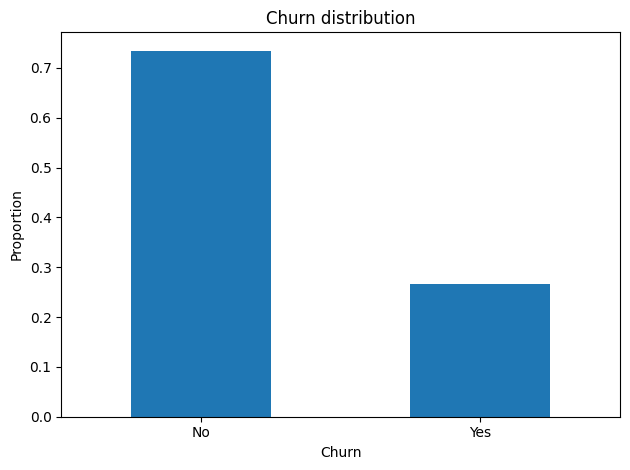

In [8]:
churn_counts = df["Churn"].value_counts(normalize=True)
print(churn_counts)

churn_counts.plot.bar(title="Churn distribution", rot=0)
plt.ylabel("Proportion")
plt.tight_layout()
plt.show()

## 6. Feature distributions

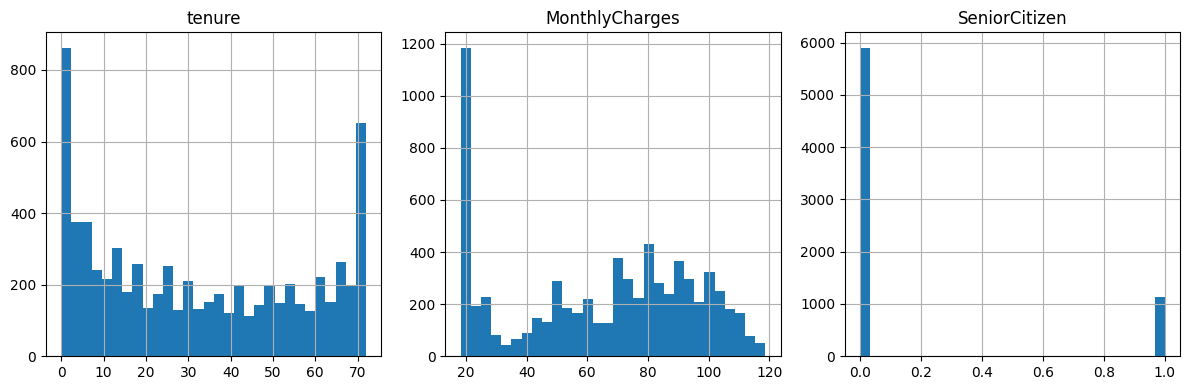

In [9]:
# Numeric features
numeric_cols = ["tenure", "MonthlyCharges", "SeniorCitizen"]
df[numeric_cols].hist(bins=30, figsize=(12, 4), layout=(1, 3))
plt.tight_layout()
plt.show()

In [10]:
# Categorical features
cat_cols = [
    "gender", "Partner", "Dependents", "PhoneService",
    "InternetService", "Contract", "PaymentMethod",
]
for col in cat_cols:
    print(f"\n--- {col} ---")
    print(df[col].value_counts())


--- gender ---
gender
Male      3555
Female    3488
Name: count, dtype: int64

--- Partner ---
Partner
No     3641
Yes    3402
Name: count, dtype: int64

--- Dependents ---
Dependents
No     4933
Yes    2110
Name: count, dtype: int64

--- PhoneService ---
PhoneService
Yes    6361
No      682
Name: count, dtype: int64

--- InternetService ---
InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

--- Contract ---
Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

--- PaymentMethod ---
PaymentMethod
Electronic check             2365
Mailed check                 1612
Bank transfer (automatic)    1544
Credit card (automatic)      1522
Name: count, dtype: int64


## 7. Correlations

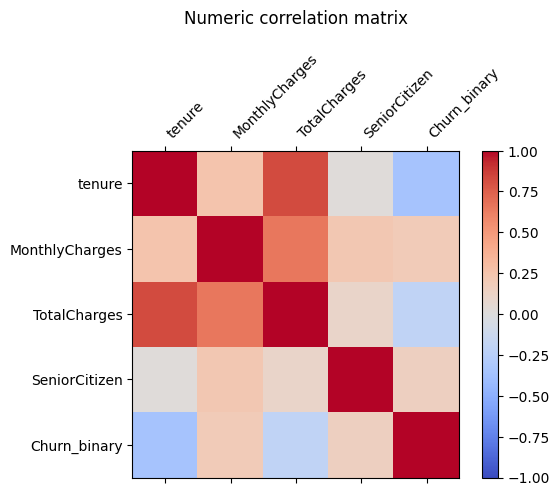

In [11]:
df_num = df.copy()
df_num["TotalCharges"] = pd.to_numeric(df_num["TotalCharges"], errors="coerce").fillna(0)
df_num["Churn_binary"] = (df_num["Churn"] == "Yes").astype(int)

corr_cols = ["tenure", "MonthlyCharges", "TotalCharges", "SeniorCitizen", "Churn_binary"]
corr = df_num[corr_cols].corr()

fig, ax = plt.subplots(figsize=(6, 5))
cax = ax.matshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
fig.colorbar(cax)
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha="left")
ax.set_yticklabels(corr.columns)
ax.set_title("Numeric correlation matrix", pad=20)
plt.tight_layout()
plt.show()

## 8. Final observations (real data)

### Dataset and quality checks

- **Shape:** **7,043 rows x 21 columns**.
- **Column quality:** all expected columns present; no duplicate columns.
- **Missingness:** `isnull()` reports 0 explicit missing values, but `TotalCharges` has **11 hidden missing entries** after numeric coercion (`errors='coerce'`).
- **Duplicates:** **0 duplicate rows**; `customerID` is unique for all rows.

### Target profile

- **Churn distribution:** `Yes = 1,869 (26.54%)`, `No = 5,174 (73.46%)`.
- This is a moderate class imbalance, so stratified train/test splitting is necessary.

### Useful churn signals seen in EDA

- **Contract type:** Month-to-month customers have much higher churn (**42.71%**) vs one-year (**11.27%**) and two-year (**2.83%**).
- **Internet service:** Fiber optic customers churn more (**41.89%**) than DSL (**18.96%**) and no internet (**7.40%**).
- **Payment method:** Electronic check customers show highest churn (**45.29%**).
- **Numeric trends:** Churn is negatively related to tenure (~**-0.35**) and mildly positively related to monthly charges (~**+0.19**).

### Preprocessing-relevant implications

- Convert `TotalCharges` to numeric and handle 11 coerced missing values (fill or impute consistently).
- Drop `customerID` before modeling (identifier only).
- Encode Yes/No binary columns to 0/1.
- One-hot encode multi-category columns (`Contract`, `InternetService`, `PaymentMethod`, etc.).
- Keep stratified splits for model evaluation.

These findings directly inform `features.preprocess.build_feature_matrix` and `features.preprocess.split_data`.